<a href="https://colab.research.google.com/github/Kamalashrinithi19/kamalashrinithi-codeboosters-2026/blob/main/Day5/Mini_Project_Day5_Weather_Intelligence_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import sqlite3
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully')

In [2]:
API_KEY='83165d8cec0a18efc84051384b5df35f'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'

CITIES = [
    'Mumbai', 'Tirupur', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata',
    'Coimbatore', 'Jaipur', 'Tirunelveli', 'Trichy', 'Sivakasi', 'Madurai',
    'Dindigul', 'Karur', 'Salem', 'Vellore',
    'Delhi', 'Pune', 'Nagpur', 'Surat', 'Ahmedabad', 'Lucknow', 'Kanpur',
    'Patna', 'Bhopal', 'Indore', 'Vadodara', 'Rajkot', 'Nashik', 'Aurangabad',
    'Amritsar', 'Ludhiana', 'Jalandhar', 'Agra', 'Varanasi', 'Allahabad',
    'Meerut', 'Ghaziabad', 'Noida', 'Faridabad', 'Gurgaon', 'Chandigarh',
    'Shimla', 'Dehradun', 'Ranchi', 'Jamshedpur', 'Bhubaneswar', 'Cuttack',
    'Guwahati', 'Shillong', 'Imphal', 'Aizawl', 'Kohima', 'Gangtok',
    'Pondicherry', 'Thoothukudi', 'Erode', 'Palakkad', 'Thrissur', 'Kochi',
    'Thiruvananthapuram', 'Kozhikode', 'Mangalore', 'Udupi', 'Belgaum',
    'Hubli', 'Dharwad', 'Mysore', 'Hosur', 'Nagercoil', 'Kanyakumari',
    'Tiruppur', 'Tiruvannamalai', 'Villupuram', 'Cuddalore', 'Kanchipuram',
    'Thanjavur', 'Nagapattinam', 'Pudukkottai', 'Virudhunagar',
    'Ramanathapuram', 'Namakkal', 'Krishnagiri', 'Dharmapuri', 'Ariyalur',
    'Perambalur', 'Chittoor', 'Vijayawada', 'Visakhapatnam',
    'Guntur', 'Nellore', 'Warangal', 'Karimnagar', 'Nizamabad', 'Adilabad',
    'Mahbubnagar', 'Kurnool', 'Anantapur', 'Raipur', 'Bilaspur', 'Durg',
    'Korba', 'Jabalpur', 'Satna', 'Rewa', 'Sagar', 'Ujjain', 'Hoshangabad',
    'Gwalior', 'Aligarh', 'Moradabad', 'Bareilly', 'Saharanpur', 'Roorkee',
    'Haridwar', 'Panaji', 'Mapusa',
    # International cities
    'New York', 'Los Angeles', 'Chicago', 'San Francisco', 'London',
    'Paris', 'Berlin', 'Rome', 'Madrid', 'Lisbon', 'Tokyo', 'Osaka',
    'Seoul', 'Beijing', 'Shanghai', 'Hong Kong', 'Singapore', 'Dubai',
    'Abu Dhabi', 'Doha', 'Sydney', 'Kansas City', 'Melbourne', 'Toronto', 'Vancouver',
    'Mexico City', 'Buenos Aires', 'Rio de Janeiro', 'Cape Town',
    'Johannesburg', 'Nairobi', 'Atlanta', 'Boston', 'Dallas', 'Houston',
    'Phoenix', 'San Antonio', 'San Diego', 'Philadelphia',
    'San Jose', 'Austin', 'Jacksonville',
    'Fort Worth', 'Charlotte', 'Indianapolis', 'Seattle',
    'Denver', 'Washington', 'Detroit', 'El Paso', 'Memphis', 'Nashville',
    'Oklahoma City', 'Louisville', 'Milwaukee', 'Baltimore', 'Albuquerque',
    'Tucson', 'Fresno', 'Sacramento', 'Mesa', 'Omaha',
    'Colorado Springs', 'Raleigh', 'Miami', 'Long Beach', 'Virginia Beach',
    'Oakland', 'Minneapolis', 'Tulsa', 'Arlington', 'New Orleans',
    'Wichita', 'Cleveland', 'Tampa', 'Bakersfield', 'Aurora', 'Anaheim',
    'Honolulu', 'Santa Ana', 'Riverside', 'Corpus Christi', 'Lexington',
    'Stockton', 'Henderson', 'Saint Paul', 'St. Louis', 'Cincinnati',
    'Pittsburgh', 'Greensboro', 'Anchorage', 'Plano', 'Lincoln',
    'Orlando', 'Irvine', 'Newark', 'Durham', 'Chula Vista', 'Toledo',
    'Fort Wayne', 'St. Petersburg', 'Laredo', 'Jersey City', 'Chandler',
    'Madison', 'Lubbock', 'Scottsdale', 'Reno', 'Buffalo', 'Gilbert',
    'Glendale', 'North Las Vegas', 'Winston-Salem', 'Norfolk', 'Chesapeake',
    'Garland', 'Irving', 'Hialeah', 'Fremont', 'Boise', 'Richmond',
    'Baton Rouge', 'Spokane', 'Des Moines', 'Tacoma', 'San Bernardino',
    'Modesto', 'Fontana', 'Oxnard', 'Moreno Valley', 'Fayetteville',
    'Huntington Beach', 'Yonkers', 'Montgomery', 'Amarillo', 'Little Rock',
    'Akron', 'Columbus', 'Augusta', 'Grand Rapids', 'Salt Lake City',
    'Tallahassee', 'Overland Park', 'Knoxville', 'Worcester', 'Brownsville',
    'Tempe', 'Santa Clarita', 'Shreveport', 'Mobile', 'Newport News',
    'Cape Coral', 'Peoria', 'Sioux Falls', 'Springfield', 'Pembroke Pines',
    'Evansville', 'Savannah', 'Dayton', 'Clarksville', 'Palmdale',
    'Salinas', 'Pasadena', 'Macon', 'Pomona',
    'Alexandria', 'Lakewood', 'Sunnyvale', 'Escondido',
    'Hollywood', 'Bridgeport', 'Paterson', 'Naperville', 'Rockford',
    'Torrance', 'Joliet', 'Bellevue', 'Midland', 'Denton', 'Roseville',
    'Thornton', 'Miramar', 'Mesquite', 'Olathe',
    'Carrollton', 'Waco', 'Sterling Heights', 'West Valley City',
    'Columbia', 'Kansas City', 'Elk Grove', 'Garden Grove'
]

print(f"API configured for {len(CITIES)} cities")
print(f"Cities: {CITIES}")

API configured for 309 cities
Cities: ['Mumbai', 'Tirupur', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Coimbatore', 'Jaipur', 'Tirunelveli', 'Trichy', 'Sivakasi', 'Madurai', 'Dindigul', 'Karur', 'Salem', 'Vellore', 'Delhi', 'Pune', 'Nagpur', 'Surat', 'Ahmedabad', 'Lucknow', 'Kanpur', 'Patna', 'Bhopal', 'Indore', 'Vadodara', 'Rajkot', 'Nashik', 'Aurangabad', 'Amritsar', 'Ludhiana', 'Jalandhar', 'Agra', 'Varanasi', 'Allahabad', 'Meerut', 'Ghaziabad', 'Noida', 'Faridabad', 'Gurgaon', 'Chandigarh', 'Shimla', 'Dehradun', 'Ranchi', 'Jamshedpur', 'Bhubaneswar', 'Cuttack', 'Guwahati', 'Shillong', 'Imphal', 'Aizawl', 'Kohima', 'Gangtok', 'Pondicherry', 'Thoothukudi', 'Erode', 'Palakkad', 'Thrissur', 'Kochi', 'Thiruvananthapuram', 'Kozhikode', 'Mangalore', 'Udupi', 'Belgaum', 'Hubli', 'Dharwad', 'Mysore', 'Hosur', 'Nagercoil', 'Kanyakumari', 'Tiruppur', 'Tiruvannamalai', 'Villupuram', 'Cuddalore', 'Kanchipuram', 'Thanjavur', 'Nagapattinam', 'Pudukkottai', 'Virudhunagar', 'Ramanathapuram', 

In [13]:
import requests

# Call API for each city

def fetch_weather(city, api_key):
  params = {
      'q': city,
      'appid' : api_key,
      'units' : 'metric'
  }

  try:
    response = requests.get(BASE_URL, params=params, timeout=10)
    if response.status_code==200:
      data=response.json()

      return {
          'city': city,
            'temperature': round(data['main']['temp'], 1),
            'feels_like': round(data['main']['feels_like'], 1),
            'humidity': data['main']['humidity'],
            'pressure': data['main']['pressure'],
            'wind_speed': data['wind']['speed'],
            'condition': data['weather'][0]['description'].title(),
            'visibility': data.get('visibility', 0)
      }
    else:
       print(f'Error {response.status_code}')
       return None
  except requests.exceptions.ConnectionError:
    print(f'Connection error for city: {city}')
    return None
  except requests.exceptions.Timeout:
    print(f"Timeout Error for {city} - Didn't response in 10 seconds")
    return None

print('Calling weather API')
weather_records = []

for city in CITIES:
  print(f'Fetching: {city}...', end='')
  record=fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f"{record['temperature']}°C, {record['condition']}")
    print(record)
  else:
    print('FAILED')
print(f'\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities')

Calling weather API
Fetching: Mumbai...30.4°C, Clear Sky
{'city': 'Mumbai', 'temperature': 30.4, 'feels_like': 37.3, 'humidity': 74, 'pressure': 1007, 'wind_speed': 6.79, 'condition': 'Clear Sky', 'visibility': 10000}
Fetching: Tirupur...33.5°C, Overcast Clouds
{'city': 'Tirupur', 'temperature': 33.5, 'feels_like': 35.5, 'humidity': 44, 'pressure': 1007, 'wind_speed': 7.15, 'condition': 'Overcast Clouds', 'visibility': 10000}
Fetching: Bangalore...29.3°C, Overcast Clouds
{'city': 'Bangalore', 'temperature': 29.3, 'feels_like': 31.2, 'humidity': 58, 'pressure': 1008, 'wind_speed': 14.31, 'condition': 'Overcast Clouds', 'visibility': 10000}
Fetching: Chennai...38.1°C, Overcast Clouds
{'city': 'Chennai', 'temperature': 38.1, 'feels_like': 45.1, 'humidity': 44, 'pressure': 1005, 'wind_speed': 3.58, 'condition': 'Overcast Clouds', 'visibility': 10000}
Fetching: Hyderabad...36.8°C, Scattered Clouds
{'city': 'Hyderabad', 'temperature': 36.8, 'feels_like': 37.4, 'humidity': 30, 'pressure': 100

In [14]:
import pandas as pd

weather_df=pd.DataFrame(weather_records)

print('Weather Dataframe created:')
print(weather_df.to_string(index=False))
print(f'\nShape: {weather_df.shape}')
print(f'Missing values: {weather_df.isnull().sum().sum()}')
print(f'\nData  types:')
print(weather_df.dtypes)

Weather Dataframe created:
              city  temperature  feels_like  humidity  pressure  wind_speed            condition  visibility
            Mumbai         30.4        37.3        74      1007        6.79            Clear Sky       10000
           Tirupur         33.5        35.5        44      1007        7.15      Overcast Clouds       10000
         Bangalore         29.3        31.2        58      1008       14.31      Overcast Clouds       10000
           Chennai         38.1        45.1        44      1005        3.58      Overcast Clouds       10000
         Hyderabad         36.8        37.4        30      1004        4.25     Scattered Clouds       10000
           Kolkata         41.1        44.8        29      1000        5.82            Clear Sky       10000
        Coimbatore         31.9        33.9        49      1008        7.52      Overcast Clouds       10000
            Jaipur         39.4        39.5        23      1001        4.83            Clear Sky     

In [15]:
print(f'Missing values: {weather_df.isnull().sum().sum()}')
print(f'Duplicates: {weather_df.duplicated().sum()}')

print('No missing values!')

Missing values: 0
Duplicates: 1
No missing values!


In [16]:
print(f'Duplicates: {weather_df[weather_df.duplicated()]}')

# Drop duplicates
weather_df.drop_duplicates(inplace=True)
print(f'Duplicates: {weather_df.duplicated().sum()}')
print("Duplicates removed successfully!")

Duplicates:             city  temperature  feels_like  humidity  pressure  wind_speed  \
306  Kansas City         20.7        20.7        71      1018        3.71   

           condition  visibility  
306  Overcast Clouds       10000  
Duplicates: 0
Duplicates removed successfully!


## Data Visualization

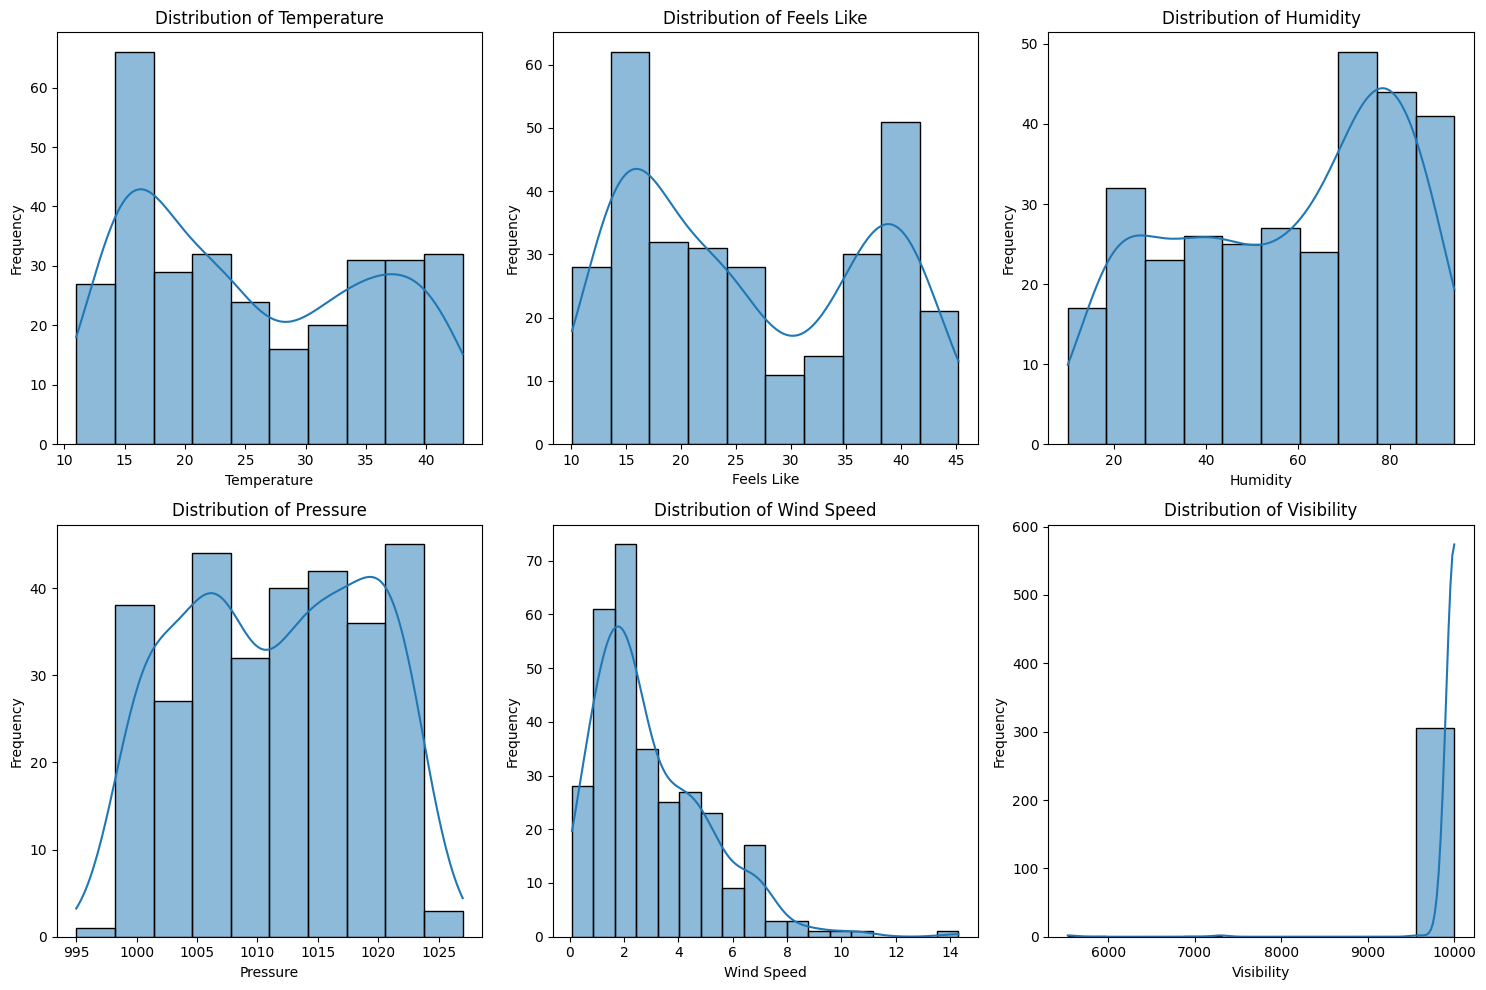

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['temperature', 'feels_like', 'humidity', 'pressure', 'wind_speed', 'visibility']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(weather_df[col], kde=True)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Now, let's look at the distribution of weather conditions.

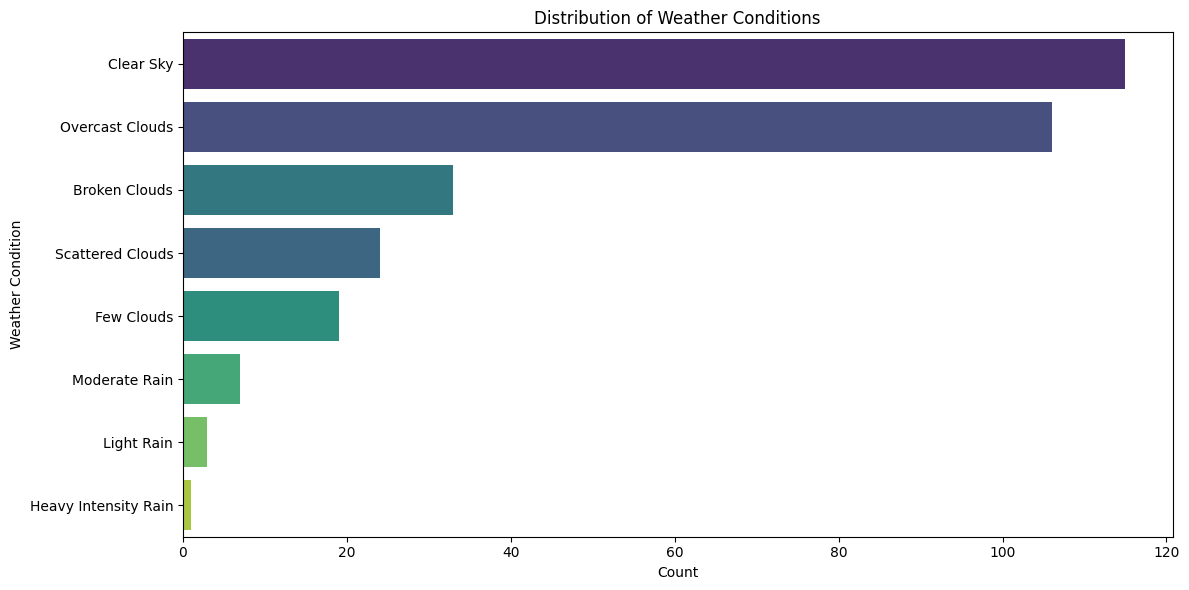

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(y='condition', data=weather_df, order=weather_df['condition'].value_counts().index, palette='viridis', hue='condition', legend=False)
plt.title('Distribution of Weather Conditions')
plt.xlabel('Count')
plt.ylabel('Weather Condition')
plt.tight_layout()
plt.show()